In [2]:
import numpy as np
from pathlib import Path

processed_path = Path("/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/splits/processed_data.npz")

data = np.load(processed_path)

print(data.files)

['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'gaia_wavelength', 'sdss_wavelength']


In [3]:
# Datos de entrada Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Errores de Gaia
X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# IDs de Gaia
X_id_train = data["X_id_train"]
X_id_val = data["X_id_val"]
X_id_test = data["X_id_test"]

# Datos objetivo SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de SDSS
y_id_train = data["y_id_train"]
y_id_val = data["y_id_val"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

In [5]:
# Normalizamos los datos
X_mean = X_train.mean()
X_std = X_train.std()

y_mean = y_train.mean()
y_std = y_train.std()

X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

y_train_norm = (y_train - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std
y_test_norm = (y_test - y_mean) / y_std

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

n_gaia = X_train.shape[1]
n_sdss = y_train.shape[1]

model = models.Sequential([
    layers.Input(shape=(n_gaia,)),

    layers.Dense(512),#, activation="elu"),#relu
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm = 1.0),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       103,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,460,586 (20.83 MB)

 Trainable params: 5,460,586 (20.83 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5, # 4 EN SU OPTIMO ESTADO, 
    min_delta = 1e-4,
    restore_best_weights=True
)

from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train_norm,
    y_train_norm,
    validation_data=(X_val_norm, y_val_norm),
    epochs=50,
    batch_size=64, #32 PARA QUE VAYA EN SU OPTIMO ESTADO
    callbacks=[early_stop,reduce_lr],
    verbose=1
)


Epoch 1/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - loss: 0.0664 - mae: 0.2109 - mse: 0.1623 - val_loss: 0.0141 - val_mae: 0.0964 - val_mse: 0.0310 - learning_rate: 1.0000e-04
Epoch 2/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - loss: 0.0128 - mae: 0.0913 - mse: 0.0273 - val_loss: 0.0124 - val_mae: 0.0874 - val_mse: 0.0273 - learning_rate: 1.0000e-04
Epoch 3/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 14s 28ms/step - loss: 0.0117 - mae: 0.0876 - mse: 0.0251 - val_loss: 0.0116 - val_mae: 0.0846 - val_mse: 0.0258 - learning_rate: 1.0000e-04
Epoch 4/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - loss: 0.0107 - mae: 0.0843 - mse: 0.0231 - val_loss: 0.0130 - val_mae: 0.0919 - val_mse: 0.0284 - learning_rate: 1.0000e-04
Epoch 5/50
488/489 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0100 - mae: 0.0825 - mse: 0.0216
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
489/489 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - loss: 0.0100 - mae: 0.0825 - mse: 0.0216 - val_loss: 0.0139 - v

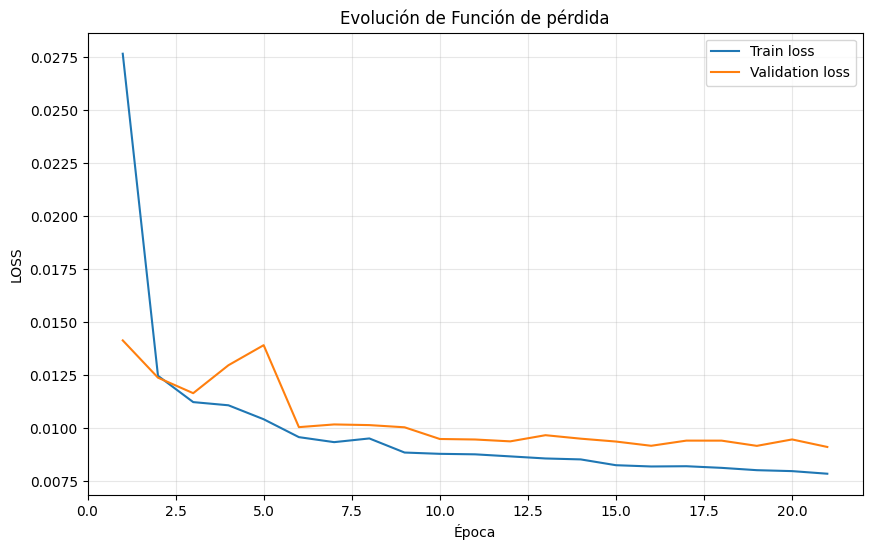

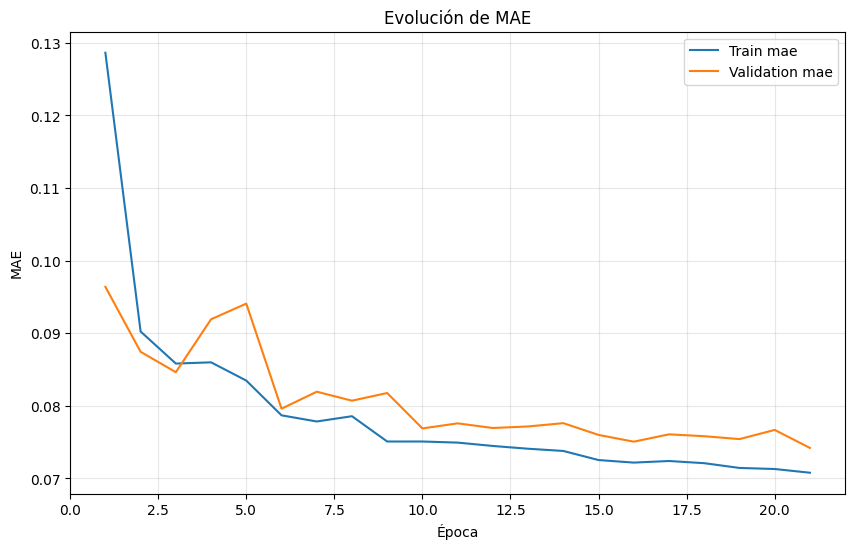

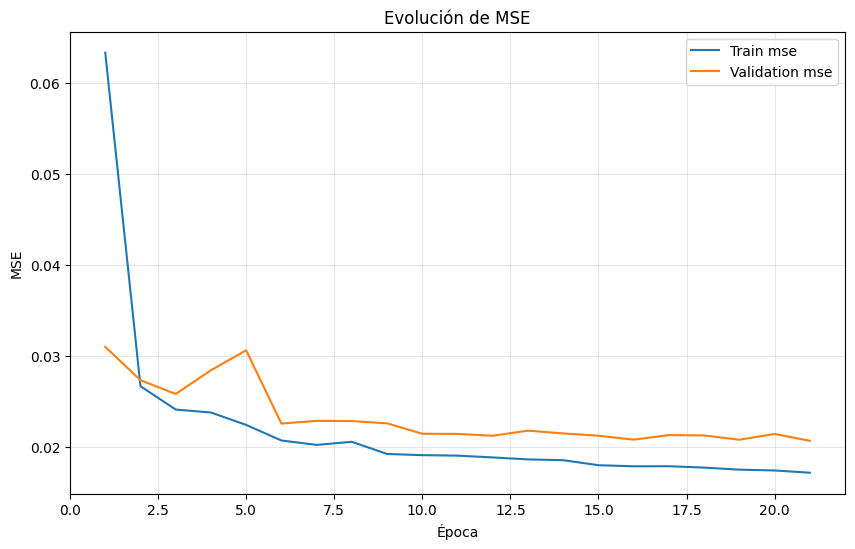

In [8]:
import matplotlib.pyplot as plt

history_dict = history.history
epochs = range(1, len(history_dict["loss"]) + 1)

metrics = [
    ("loss", "Función de pérdida"),
    ("mae", "MAE"),
    ("mse", "MSE")
]

for metric, title in metrics:
    plt.figure(figsize=(10, 6))

    plt.plot(epochs, history_dict[metric], label=f"Train {metric}")
    plt.plot(epochs, history_dict[f"val_{metric}"], label=f"Validation {metric}")

    plt.xlabel("Época")
    plt.ylabel(metric.upper())
    plt.title(f"Evolución de {title}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [9]:
y_pred_norm = model.predict(X_test_norm)
y_pred = y_pred_norm * y_std + y_mean

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


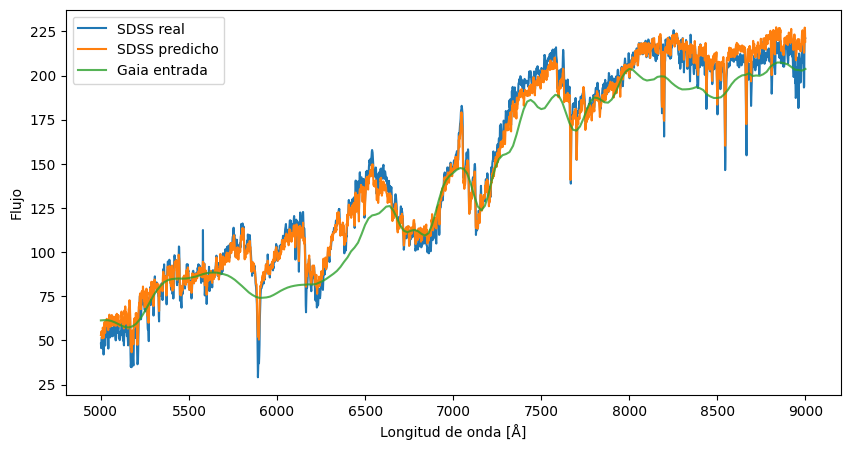

In [14]:
import matplotlib.pyplot as plt

i = 123
#, 23, 178

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred[i], label="SDSS predicho")
plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

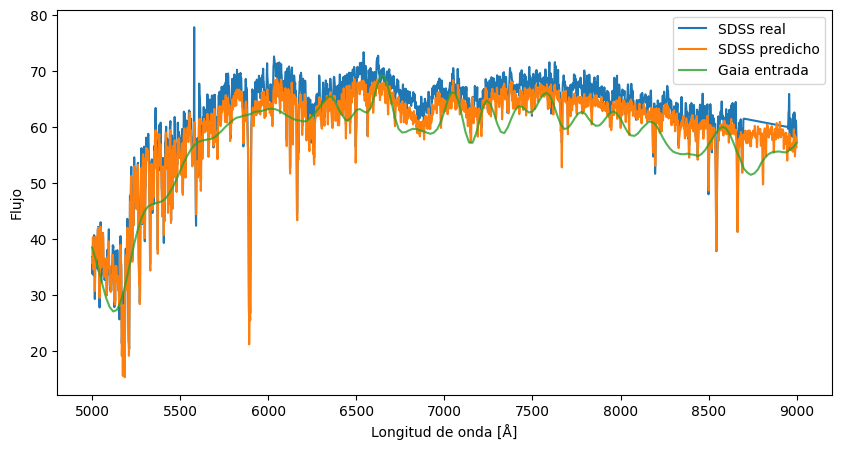

In [15]:

i = 191
#, 23, 178

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength, y_pred[i], label="SDSS predicho")
plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()

In [12]:
test_loss, test_mae, test_mse = model.evaluate(
    X_test_norm,
    y_test_norm,
    verbose=1
)

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0086 - mae: 0.0735 - mse: 0.0181


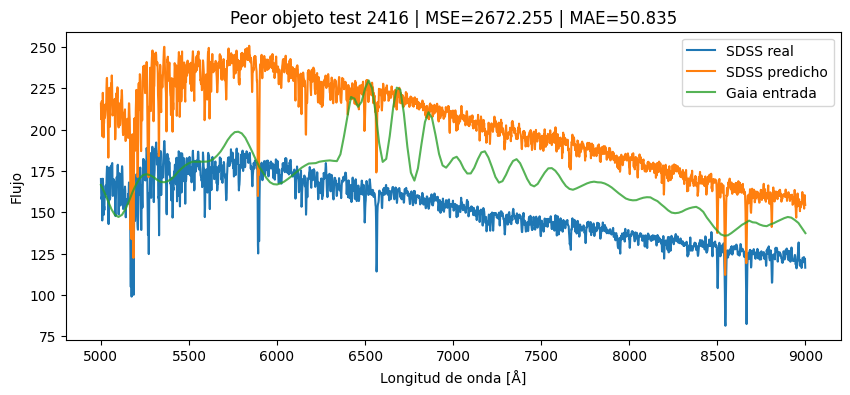

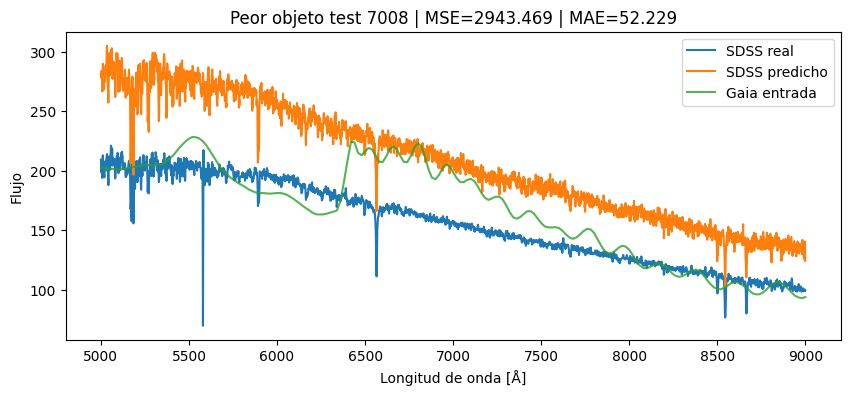

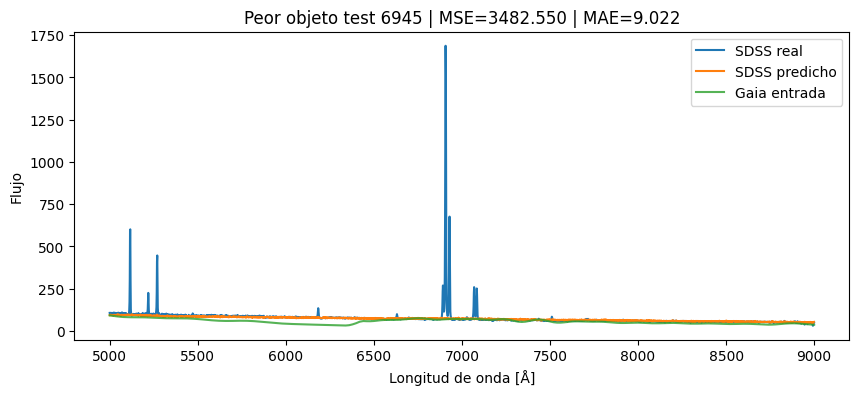

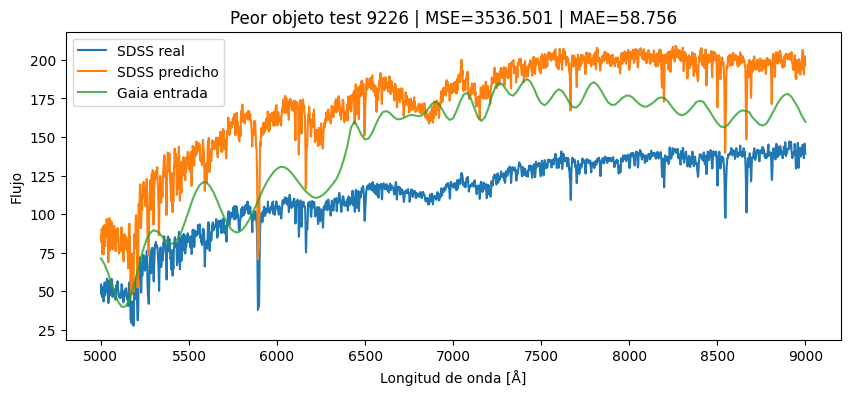

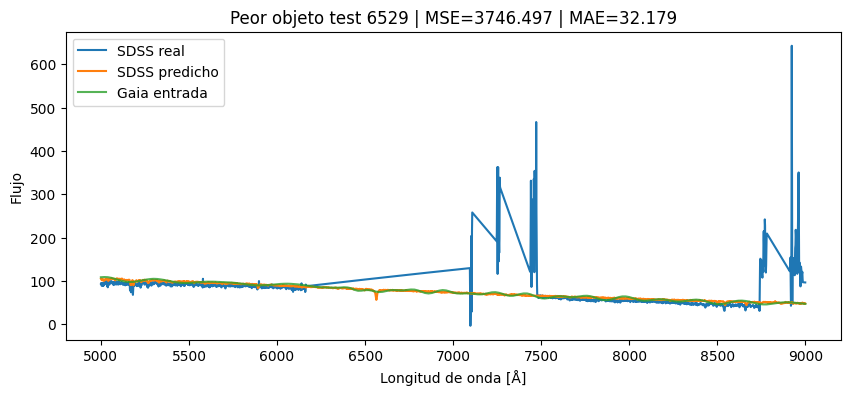

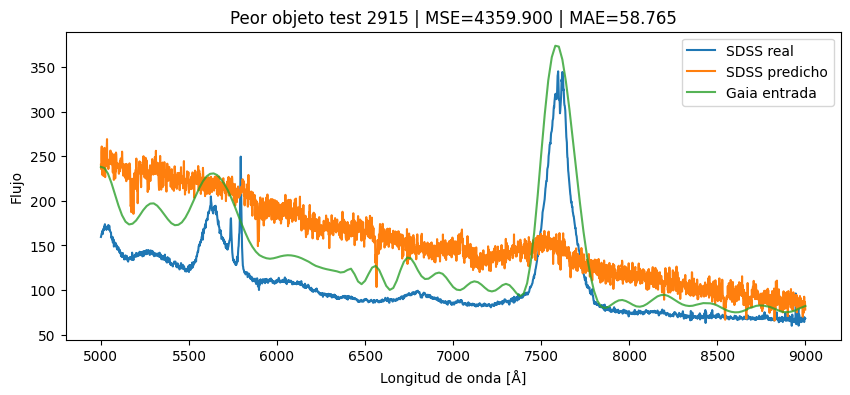

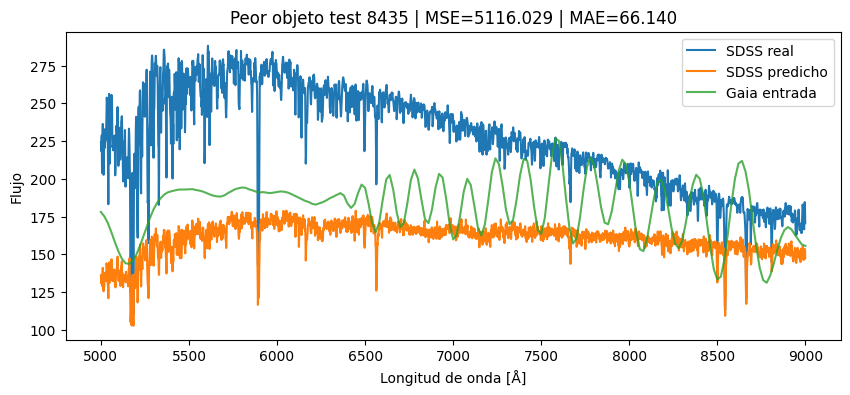

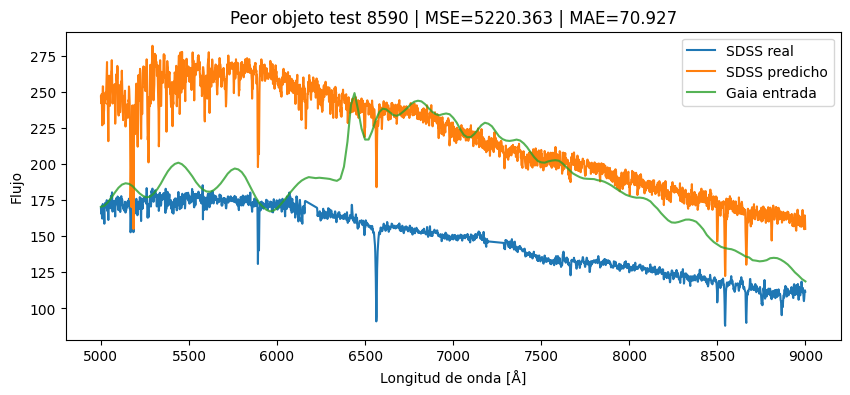

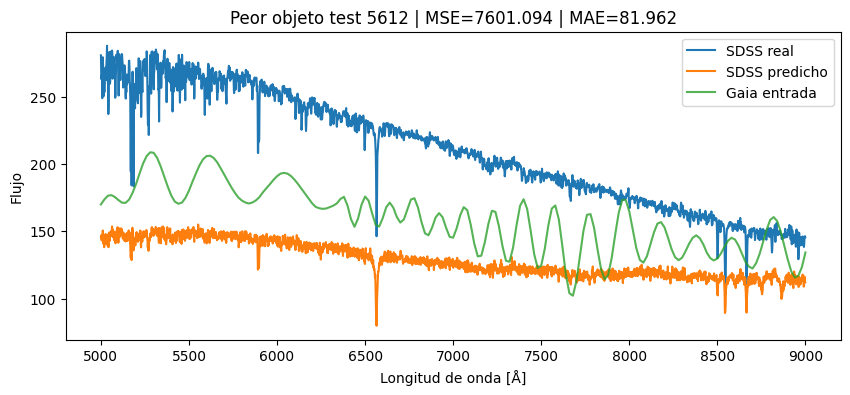

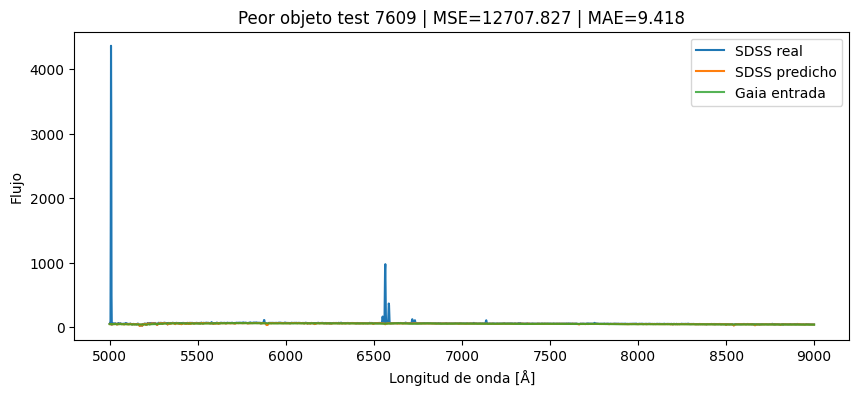

In [16]:
mae = np.mean(np.abs(y_test - y_pred))
mse = np.mean((y_test - y_pred) ** 2)
rmse = np.sqrt(mse)

mae_per_object = np.mean(np.abs(y_test - y_pred), axis=1)
mse_per_object = np.mean((y_test - y_pred) ** 2, axis=1)
rmse_per_object = np.sqrt(mse_per_object)

worst_idx = np.argsort(mse_per_object)[-10:]

for i in worst_idx:

    plt.figure(figsize=(10, 4))
    plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
    plt.plot(sdss_wavelength, y_pred[i], label="SDSS predicho")
    plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
    plt.xlabel("Longitud de onda [Å]")
    plt.ylabel("Flujo")
    plt.title(f"Peor objeto test {i} | MSE={mse_per_object[i]:.3f} | MAE={mae_per_object[i]:.3f}")
    plt.legend()
    plt.show()

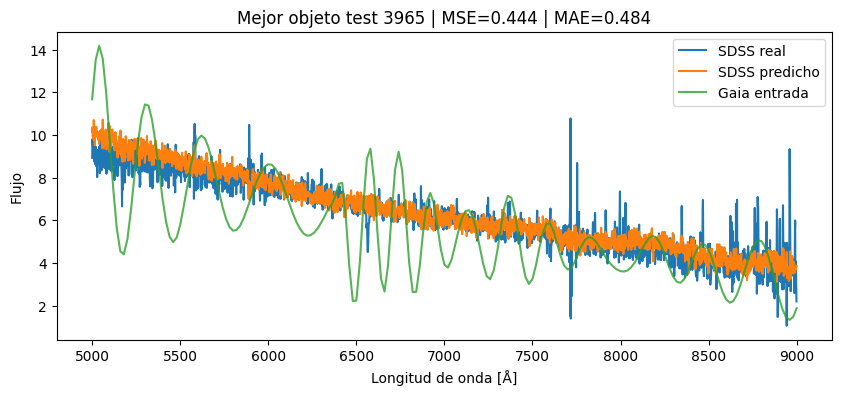

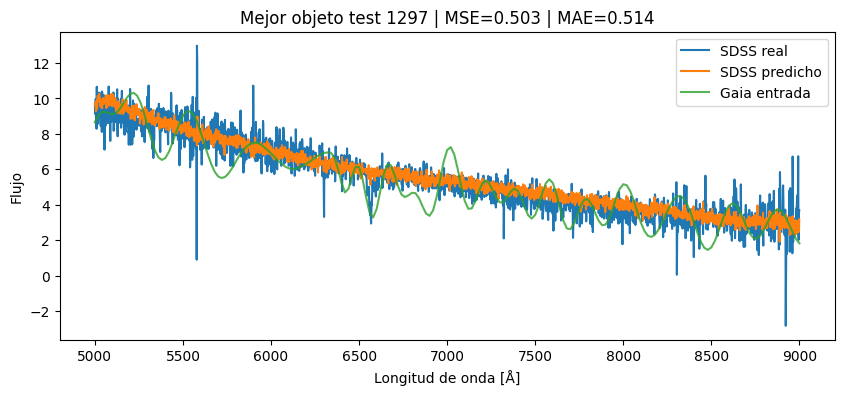

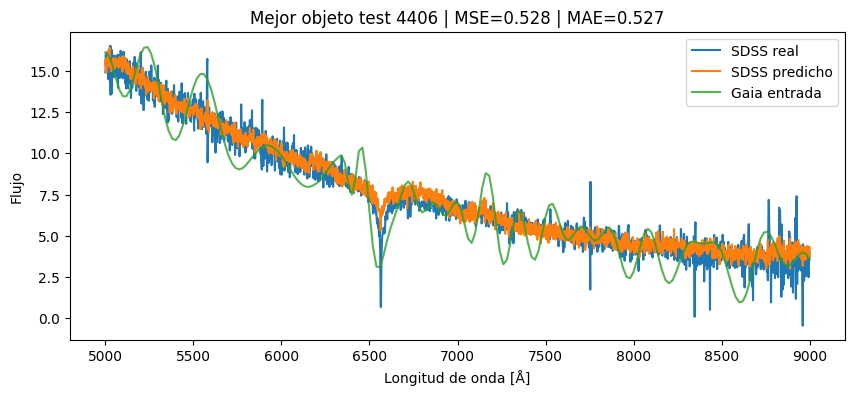

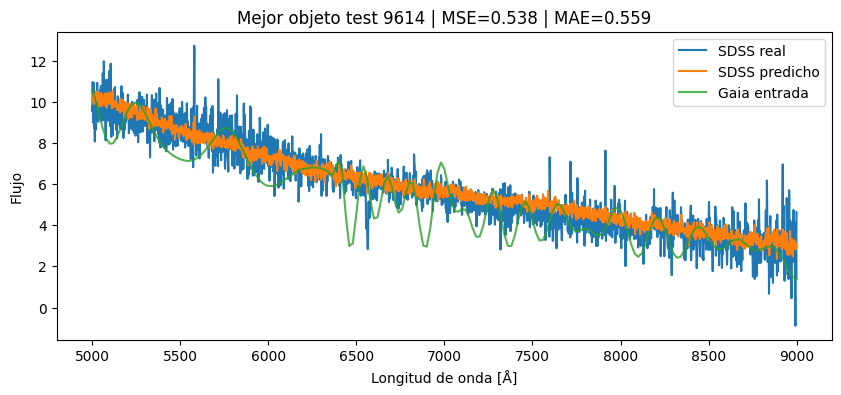

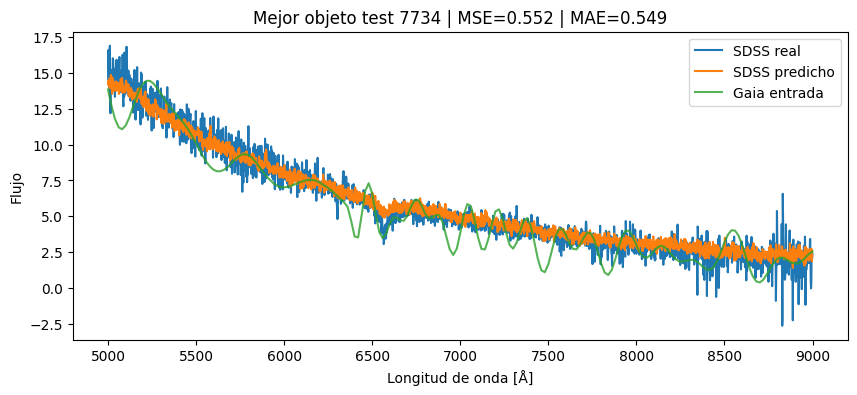

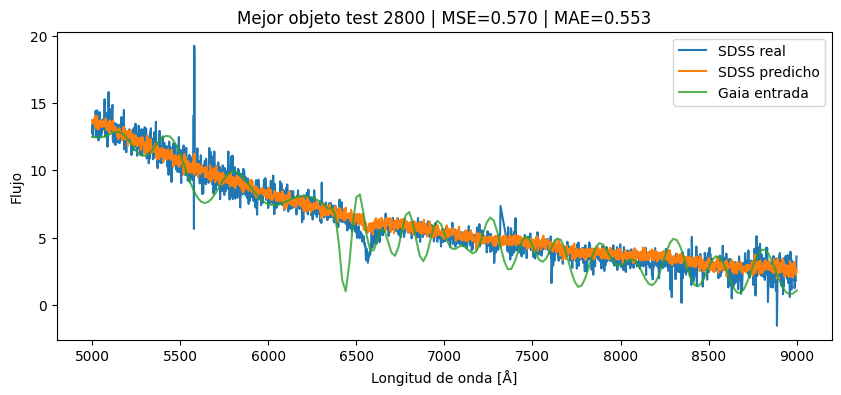

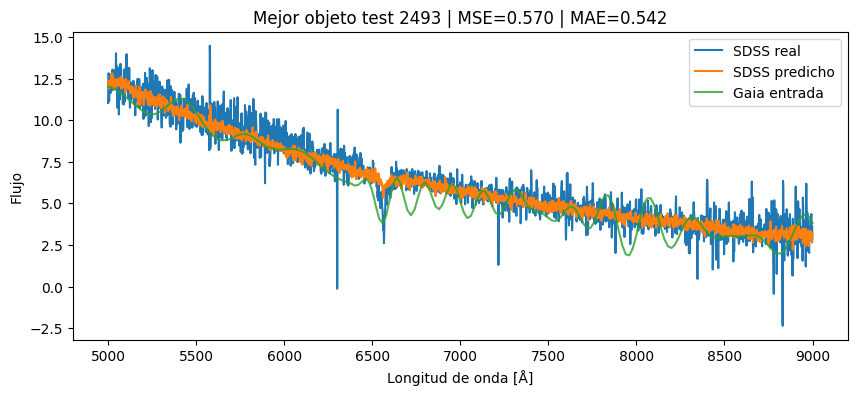

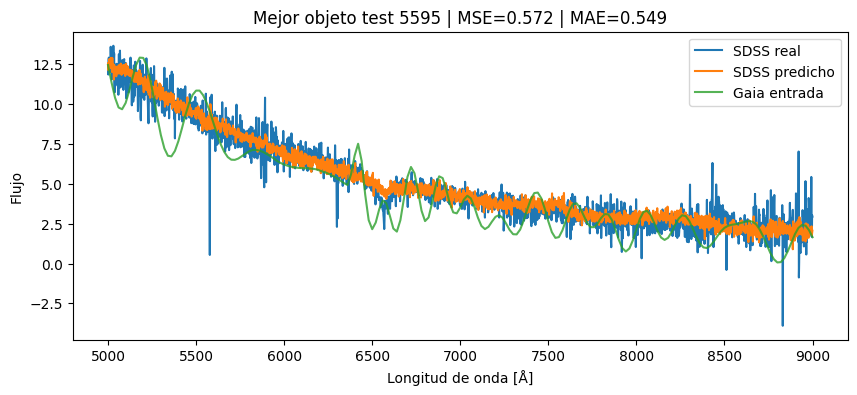

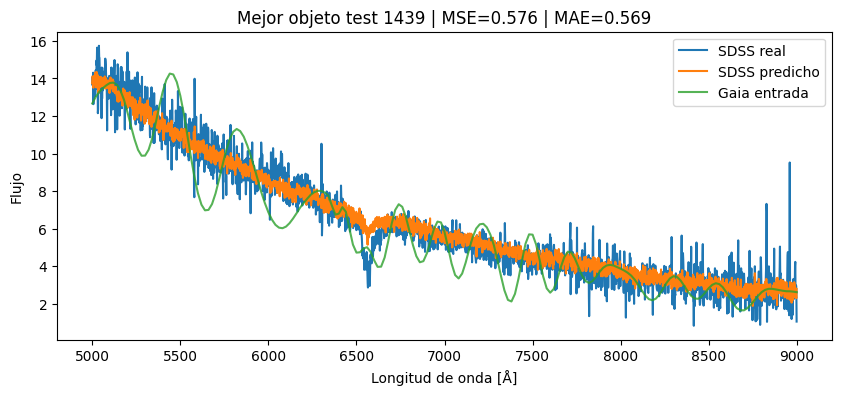

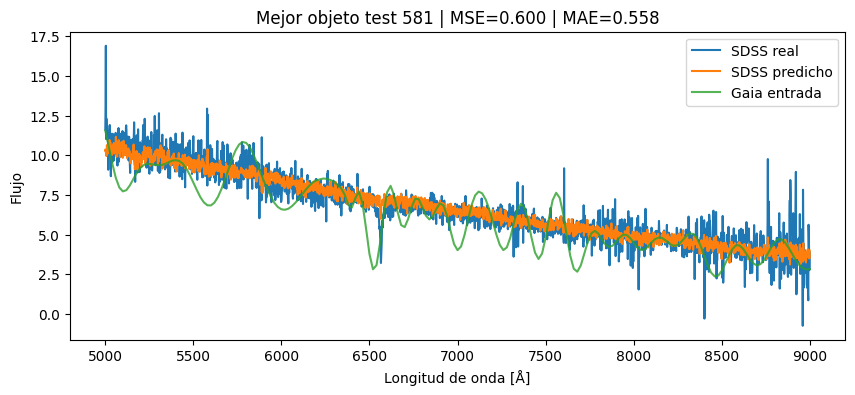

In [17]:
best_idx = np.argsort(mse_per_object)[:10]

for i in best_idx:
    plt.figure(figsize=(10, 4))
    plt.plot(sdss_wavelength, y_test[i], label="SDSS real")
    plt.plot(sdss_wavelength, y_pred[i], label="SDSS predicho")
    plt.plot(gaia_wavelength, X_test[i], label="Gaia entrada", alpha=0.8)
    plt.xlabel("Longitud de onda [Å]")
    plt.ylabel("Flujo")
    plt.title(f"Mejor objeto test {i} | MSE={mse_per_object[i]:.3f} | MAE={mae_per_object[i]:.3f}")
    plt.legend()
    plt.show()

Probamos un modelo diferente par capas convolucionales

In [ ]:
n_gaia = X_train_norm.shape[1]
n_sdss = y_train_norm.shape[1]

# Para Conv1D necesitamos forma (n_objetos, n_puntos, canales)
X_train_cnn = X_train_norm[..., None]
X_val_cnn = X_val_norm[..., None]
X_test_cnn = X_test_norm[..., None]

model_cnn = models.Sequential([
    layers.Input(shape=(n_gaia, 1)),

    layers.Conv1D(32, kernel_size=7, padding="same", activation="elu"),
    layers.Conv1D(64, kernel_size=7, padding="same", activation="elu"),
    layers.Conv1D(128, kernel_size=5, padding="same", activation="elu"),

    layers.Flatten(),

    layers.Dense(512),#, activation="elu"),#relu
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),
    
    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

model_cnn.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1),
    loss= tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_cnn.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 201, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 201, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 201, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 512)            │    13,173,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 380)            │       389,500 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,243,004 (61.96 MB)

 Trainable params: 16,243,004 (61.96 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
history = model_cnn.fit(
    X_train_cnn,
    y_train_norm,
    validation_data=(X_val_cnn, y_val_norm),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop,reduce_lr],
    verbose=1
)

Epoch 1/50


306/306 ━━━━━━━━━━━━━━━━━━━━ 42s 130ms/step - loss: 0.1011 - mae: 0.2689 - mse: 0.3410 - val_loss: 0.0325 - val_mae: 0.1076 - val_mse: 0.1305 - learning_rate: 1.0000e-04
Epoch 2/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - loss: 0.0304 - mae: 0.1092 - mse: 0.1111 - val_loss: 0.0407 - val_mae: 0.1500 - val_mse: 0.1478 - learning_rate: 1.0000e-04
Epoch 3/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 36s 116ms/step - loss: 0.0253 - mae: 0.1028 - mse: 0.0877 - val_loss: 0.0323 - val_mae: 0.1039 - val_mse: 0.1368 - learning_rate: 1.0000e-04
Epoch 4/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 38s 124ms/step - loss: 0.0277 - mae: 0.1005 - mse: 0.1062 - val_loss: 0.0298 - val_mae: 0.1041 - val_mse: 0.1175 - learning_rate: 1.0000e-04
Epoch 5/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 36s 117ms/step - loss: 0.0293 - mae: 0.1027 - mse: 0.1102 - val_loss: 0.0283 - val_mae: 0.1007 - val_mse: 0.1152 - learning_rate: 1.0000e-04
Epoch 6/50
306/306 ━━━━━━━━━━━━━━━━━━━━ 38s 124ms/step - loss: 0.0254 - mae: 0.0990 - mse: 0.0859 - val_lo

In [81]:
test_loss, test_mae, test_mse = model_cnn.evaluate(
    X_test_cnn,
    y_test_norm,
    verbose=1
)

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0200 - mae: 0.0879 - mse: 0.0624


In [82]:
y_pred_norm_cnn = model_cnn.predict(X_test_cnn)
y_pred_cnn = y_pred_norm * y_std + y_mean
y_test_recalculated_cnn = y_test_norm * y_std + y_mean

96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


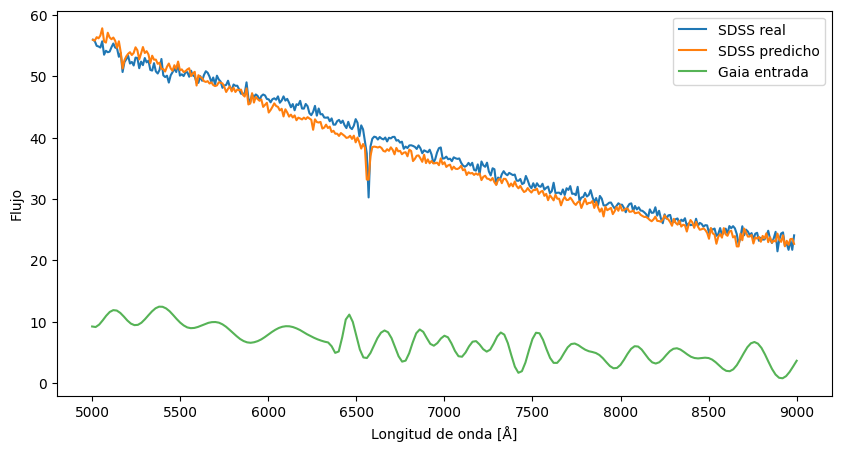

In [84]:
import matplotlib.pyplot as plt

i = 14

gaia_wavelength_ams = gaia_wavelength * 10
gaia_in_sdss_units_cnn = X_test[i] / 1e-19

plt.figure(figsize=(10, 5))
plt.plot(sdss_wavelength_binned, y_test[i], label="SDSS real")
plt.plot(sdss_wavelength_binned, y_pred_cnn[i], label="SDSS predicho")
plt.plot(gaia_wavelength_ams, gaia_in_sdss_units, label="Gaia entrada", alpha=0.8)
plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Flujo")
plt.legend()
plt.show()